# **Wine Quality Prediction**

##Data Loading

In [23]:
import pandas as pd

df = pd.read_csv('WineQT.csv')

##Data Exploration

In [24]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [25]:
df.shape

(1143, 13)

In [26]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [28]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

##Data Cleaning

In [29]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop('Id', axis=1)

##Feature Selection

In [32]:
X = df.drop('quality', axis=1)

y = df['quality']

##Train - Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Random Forest Model

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7030567685589519


##SGD Classifier

In [36]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

In [37]:
sgd_acc = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_acc)

SGD Accuracy: 0.4585152838427948


##Support Vetor Classifier

In [38]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

In [39]:
svc_acc = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_acc)

SVC Accuracy: 0.5633187772925764


##Model Comparison Visualization

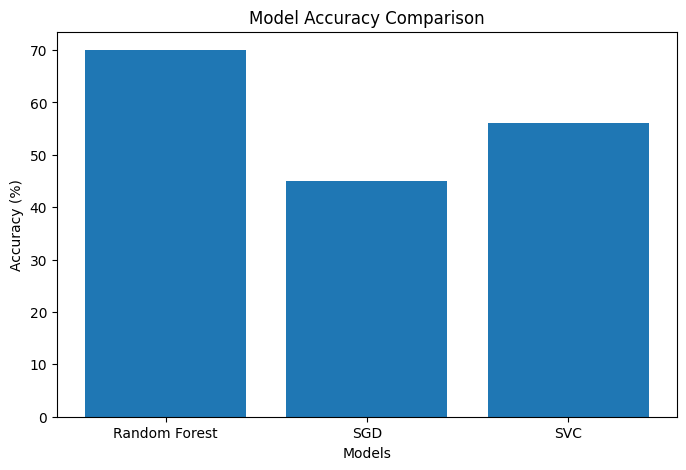

In [40]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'SGD', 'SVC']
scores = [70, 45, 56]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

plt.show()

In [41]:
sample_prediction = rf.predict(X_test[:5])

print("Predictions:", sample_prediction)
print("Actual:", y_test.iloc[:5].values)

Predictions: [5 6 5 5 5]
Actual: [5 6 5 6 6]


##Insights

1. Random Forest achieved the highest accuracy (70%).

2. SVC achieved moderate performance (56%).

3. SGD Classifier achieved the lowest accuracy (45%).

4. Alcohol, acidity, density, and sulphates are important factors affecting wine quality.

5. Random Forest handled the dataset better than the other classifiers.

##Recommendations

1. Use Random Forest for wine quality prediction.

2. Collect more wine samples for better accuracy.

3. Perform hyperparameter tuning to improve performance.

4. Analyze feature importance to understand key chemical attributes.

5. Explore advanced models such as XGBoost.

##Conclusion

A wine quality prediction system was developed using Random Forest, SGD Classifier, and SVC. Random Forest achieved the highest accuracy of 70%, making it the best-performing model. The project demonstrates the application of machine learning in predicting wine quality using chemical properties.